In [1]:

# Install required libraries (Colab has most pre-installed, this ensures versions match)
!pip install -q scikit-learn pandas numpy matplotlib seaborn xgboost streamlit pyngrok

# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
print(" Libraries installed and imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 92.6 MB/s eta 0:00:00
 Libraries installed and imported successfully!


In [2]:
from google.colab import files
uploaded = files.upload()

Saving sports_analytics.csv to sports_analytics.csv


In [3]:
# Load the dataset
df = pd.read_csv('sports_analytics.csv')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (52760, 67)


,match_id,custom_match_id,season,type_clean,competition_code,competition,gender,venue,date,timestamp,inning_number,id,overs_unique,overs_actual,over_number,ball_number,balls_remaining,total_inning_runs,run_rate,target,total_inning_wickets,bowl_team,bowl_team_id,bowl_team_abbr,bowler_cricinfo_id,bowler_player_id,bowler,bowling_hand,bowling_pacespin,bowling_style_long,bowler_wickets_cumulative,title,bat_team,bat_team_id,bat_team_abbr,batter_cricinfo_id,batter_player_id,batter,batting_style,batter_runs_cumulative,total_runs,runs_off_bat,is_four,is_six,pitch_line,pitch_length,shot_type,shot_control,wagon_x,wagon_y,wagon_zone,byes,legbyes,wides,noballs,penalties,extras,out_player_cricinfo_id,out_player_id,out_player,dismissal_type,dismissal_text_shot,dismissal_text_long,dismissal_text_commentary,is_wicket,score,winProbability
0,1304047,IPL_CSK_KKR_2022-03-26,2022,T20,IPL,Indian Premier League,male,"Wankhede Stadium, Mumbai",2022-03-26,2022-03-26T14:00:31.000Z,1,38753175,0.01,0.1,1,1,119,1,6.0,0,0,Kolkata Knight Riders,4341,KKR,376116,58274,Umesh Yadav,right-arm bowler,pace bowler,right-arm fast,0,Umesh Yadav to Gaikwad,Chennai Super Kings,4343,CSK,1060380,95094,Ruturaj Gaikwad,rhb,0,1,0,False,False,OUTSIDE_OFFSTUMP,SHORT_OF_A_GOOD_LENGTH,PUSH,2.0,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,167,50.09
1,1304047,IPL_CSK_KKR_2022-03-26,2022,T20,IPL,Indian Premier League,male,"Wankhede Stadium, Mumbai",2022-03-26,2022-03-26T14:01:05.000Z,1,38753178,0.02,0.1,1,2,118,1,6.0,0,0,Kolkata Knight Riders,4341,KKR,376116,58274,Umesh Yadav,right-arm bowler,pace bowler,right-arm fast,0,Umesh Yadav to Gaikwad,Chennai Super Kings,4343,CSK,1060380,95094,Ruturaj Gaikwad,rhb,0,0,0,False,False,OUTSIDE_OFFSTUMP,FULL,COVER_DRIVE,2.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,166,48.96
2,1304047,IPL_CSK_KKR_2022-03-26,2022,T20,IPL,Indian Premier League,male,"Wankhede Stadium, Mumbai",2022-03-26,2022-03-26T14:01:32.000Z,1,38753182,0.03,0.2,1,3,117,2,6.0,0,0,Kolkata Knight Riders,4341,KKR,376116,58274,Umesh Yadav,right-arm bowler,pace bowler,right-arm fast,0,Umesh Yadav to Gaikwad,Chennai Super Kings,4343,CSK,1060380,95094,Ruturaj Gaikwad,rhb,0,1,0,False,False,DOWN_LEG,SHORT_OF_A_GOOD_LENGTH,LEG_GLANCE,NaN,0,0,0,0,0,1,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,167,50.09
3,1304047,IPL_CSK_KKR_2022-03-26,2022,T20,IPL,Indian Premier League,male,"Wankhede Stadium, Mumbai",2022-03-26,2022-03-26T14:02:21.000Z,1,38753183,0.04,0.2,1,4,116,2,6.0,0,0,Kolkata Knight Riders,4341,KKR,376116,58274,Umesh Yadav,right-arm bowler,pace bowler,right-arm fast,0,Umesh Yadav to Gaikwad,Chennai Super Kings,4343,CSK,1060380,95094,Ruturaj Gaikwad,rhb,0,0,0,False,False,OUTSIDE_OFFSTUMP,SHORT_OF_A_GOOD_LENGTH,FLICK,2.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,165,47.83
4,1304047,IPL_CSK_KKR_2022-03-26,2022,T20,IPL,Indian Premier League,male,"Wankhede Stadium, Mumbai",2022-03-26,2022-03-26T14:03:09.000Z,1,38753187,0.05,0.3,1,5,115,2,4.0,0,1,Kolkata Knight Riders,4341,KKR,376116,58274,Umesh Yadav,right-arm bowler,pace bowler,right-arm fast,1,Umesh Yadav to Gaikwad,Chennai Super Kings,4343,CSK,1060380,95094,Ruturaj Gaikwad,rhb,0,0,0,False,False,OUTSIDE_OFFSTUMP,SHORT_OF_A_GOOD_LENGTH,CUT_SHOT,2.0,167,128,8,0,0,0,0,0,0,1060380.0,95094.0,Ruturaj Gaikwad,1.0,caught,c Rana b Yadav,Ruturaj Gaikwad c Rana b Yadav 0 (4b 0x4 0x6 5...,True,163,45.58


In [4]:
# DATA EXPLORATION

print("Rows, Columns:", df.shape)
print("\n--- Data types ---")
print(df.dtypes)

Rows, Columns: (52760, 67)

--- Data types ---
match_id                       int64
custom_match_id               object
season                         int64
type_clean                    object
competition_code              object
                              ...   
dismissal_text_long           object
dismissal_text_commentary     object
is_wicket                       bool
score                          int64
winProbability               float64
Length: 67, dtype: object


In [5]:
# Check for missing values (only columns that have them)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:\n")
print(missing)

Columns with missing values:

dismissal_type               50056
out_player                   50056
out_player_id                50056
out_player_cricinfo_id       50056
dismissal_text_long          50056
dismissal_text_shot          50056
dismissal_text_commentary    50056
shot_control                  1265
shot_type                      277
pitch_line                     108
pitch_length                    94
timestamp                       39
dtype: int64


In [6]:
# HANDLE MISSING VALUES & DUPLICATES (GENERAL PURPOSE)

before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows. New shape: {df.shape}")

Removed 0 duplicate rows. New shape: (52760, 67)


In [7]:
# General function to fill missing values:
#    Numeric (int/float) columns -> filled with column MEAN
#    String/object/categorical columns -> filled with column MODE (most frequent value)

def fill_missing_values(dataframe):
    df_copy = dataframe.copy()

    for col in df_copy.columns:
        if df_copy[col].isnull().sum() == 0:
            continue  # skip columns with no missing values

        if df_copy[col].dtype in ['int64', 'float64']:
            # Numeric column -> fill with mean
            mean_val = df_copy[col].mean()
            df_copy[col] = df_copy[col].fillna(mean_val)
            print(f"[Numeric]  '{col}' -> filled {dataframe[col].isnull().sum()} missing values with mean = {round(mean_val, 2)}")

        else:
            # String / object column -> fill with mode (most frequent value)
            mode_val = df_copy[col].mode()[0]
            df_copy[col] = df_copy[col].fillna(mode_val)
            print(f"[String]   '{col}' -> filled {dataframe[col].isnull().sum()} missing values with mode = '{mode_val}'")

    return df_copy

df = fill_missing_values(df)

print("\n Missing values handled.")
print("Remaining missing values:", df.isnull().sum().sum())

[String]   'timestamp' -> filled 39 missing values with mode = '2024-04-21T14:05:04.000Z'
[String]   'pitch_line' -> filled 108 missing values with mode = 'OUTSIDE_OFFSTUMP'
[String]   'pitch_length' -> filled 94 missing values with mode = 'GOOD_LENGTH'
[String]   'shot_type' -> filled 277 missing values with mode = 'FLICK'
[Numeric]  'shot_control' -> filled 1265 missing values with mean = 1.28
[Numeric]  'out_player_cricinfo_id' -> filled 50056 missing values with mean = 622836.22
[Numeric]  'out_player_id' -> filled 50056 missing values with mean = 70342.67
[String]   'out_player' -> filled 50056 missing values with mode = 'Faf du Plessis'
[Numeric]  'dismissal_type' -> filled 50056 missing values with mean = 1.56
[String]   'dismissal_text_shot' -> filled 50056 missing values with mode = 'caught'
[String]   'dismissal_text_long' -> filled 50056 missing values with mode = ' b Patel'
[String]   'dismissal_text_commentary' -> filled 50056 missing values with mode = 'Aaron Finch b Saka

In [8]:
# How many unique matches, teams, venues do we have?
print("Unique Matches:", df['match_id'].nunique())
print("Unique Teams:", df['bat_team'].nunique())
print("Unique Venues:", df['venue'].nunique())
print("\nTeams in dataset:")
print(df['bat_team'].unique())

Unique Matches: 218
Unique Teams: 11
Unique Venues: 17

Teams in dataset:
['Chennai Super Kings' 'Kolkata Knight Riders' 'Mumbai Indians'
 'Delhi Capitals' 'Royal Challengers Bangalore' 'Punjab Kings'
 'Lucknow Super Giants' 'Gujarat Titans' 'Rajasthan Royals'
 'Sunrisers Hyderabad' 'Royal Challengers Bengaluru']


In [9]:
# Look at one full match to understand the structure (ball-by-ball)
sample_match_id = df['match_id'].unique()[0]
sample_match = df[df['match_id'] == sample_match_id]
sample_match[['inning_number', 'over_number', 'ball_number',
              'bat_team', 'bowl_team', 'total_inning_runs',
              'total_inning_wickets', 'balls_remaining',
              'target', 'run_rate', 'winProbability']].tail(10)

,inning_number,over_number,ball_number,bat_team,bowl_team,total_inning_runs,total_inning_wickets,balls_remaining,target,run_rate,winProbability
227,2,17,6,Kolkata Knight Riders,Chennai Super Kings,122,3,18,132,7.18,99.43
228,2,18,1,Kolkata Knight Riders,Chennai Super Kings,122,3,17,132,7.11,99.42
229,2,18,2,Kolkata Knight Riders,Chennai Super Kings,123,3,16,132,7.10,99.51
230,2,18,3,Kolkata Knight Riders,Chennai Super Kings,123,4,15,132,7.03,99.23
231,2,18,4,Kolkata Knight Riders,Chennai Super Kings,124,4,14,132,7.02,99.35
232,2,18,5,Kolkata Knight Riders,Chennai Super Kings,125,4,13,132,7.01,99.45
233,2,18,6,Kolkata Knight Riders,Chennai Super Kings,126,4,12,132,7.00,99.54
234,2,19,1,Kolkata Knight Riders,Chennai Super Kings,127,4,11,132,6.99,99.61
235,2,19,2,Kolkata Knight Riders,Chennai Super Kings,129,4,10,132,7.04,99.75
236,2,19,3,Kolkata Knight Riders,Chennai Super Kings,133,4,9,132,7.19,100.00


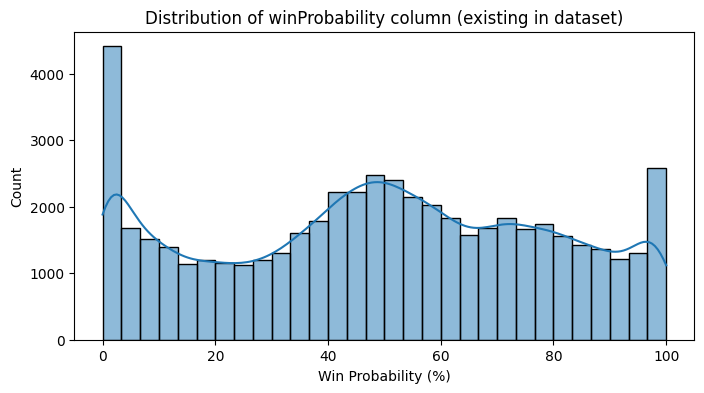

In [10]:
# Check the distribution of winProbability (this is a column already in the dataset,
# likely computed by the data provider — we will build OUR OWN model that predicts this
# from scratch, and compare against it later)
plt.figure(figsize=(8,4))
sns.histplot(df['winProbability'], bins=30, kde=True)
plt.title("Distribution of winProbability column (existing in dataset)")
plt.xlabel("Win Probability (%)")
plt.show()

In [11]:
# Quick check: how many balls belong to 1st innings vs 2nd innings?
print(df['inning_number'].value_counts())

inning_number
1    27236
2    25524
Name: count, dtype: int64


In [12]:
# FEATURE ENGINEERING

# We only care about the 2nd innings (the "chase") to predict win probability,
# since that's when "target" and "required run rate" actually make sense.
chase_df = df[df['inning_number'] == 2].copy()
print("Rows in 2nd innings (chase data):", chase_df.shape)

Rows in 2nd innings (chase data): (25524, 67)


In [13]:
# Extract city from venue string, e.g. "Wankhede Stadium, Mumbai" -> "Mumbai"
def extract_city(venue):
    if ',' in venue:
        return venue.split(',')[-1].strip()
    return venue.strip()

chase_df['city'] = chase_df['venue'].apply(extract_city)
print(chase_df['city'].value_counts())

city
Mumbai           8327
Ahmedabad        2136
Chennai          2104
Kolkata          1859
Bengaluru        1663
Lucknow          1545
Hyderabad        1526
Pune             1498
Delhi            1464
Jaipur           1129
Mullanpur         613
Chandigarh        575
Dharamsala        479
Guwahati          367
Visakhapatnam     239
Name: count, dtype: int64


In [14]:
# Core engineered features
chase_df['runs_left'] = chase_df['target'] - chase_df['total_inning_runs']
chase_df['balls_left'] = chase_df['balls_remaining']
chase_df['wickets_left'] = 10 - chase_df['total_inning_wickets']

# Balls bowled so far in this innings (used for current run rate)
chase_df['balls_bowled'] = 120 - chase_df['balls_left']   # T20 = 120 balls per innings
chase_df['balls_bowled'] = chase_df['balls_bowled'].replace(0, 1)  # avoid divide-by-zero

# Current Run Rate (CRR) = runs scored so far per over
chase_df['crr'] = (chase_df['total_inning_runs'] * 6) / chase_df['balls_bowled']

# Required Run Rate (RRR) = runs still needed per over
chase_df['balls_left_safe'] = chase_df['balls_left'].replace(0, 1)  # avoid divide-by-zero
chase_df['rrr'] = (chase_df['runs_left'] * 6) / chase_df['balls_left_safe']

print(" Engineered runs_left, balls_left, wickets_left, crr, rrr")
chase_df[['total_inning_runs','target','runs_left','balls_left','wickets_left','crr','rrr']].head()

 Engineered runs_left, balls_left, wickets_left, crr, rrr


,total_inning_runs,target,runs_left,balls_left,wickets_left,crr,rrr
126,0,132,132,119,10,0.0,6.655462
127,0,132,132,118,10,0.0,6.711864
128,0,132,132,117,10,0.0,6.769231
129,2,132,130,116,10,3.0,6.724138
130,6,132,126,115,10,7.2,6.573913


In [15]:
# Now determine the LABEL: did the chasing (batting) team win the match?
# Rule: for each match, look at the FINAL ball of the 2nd innings.
#   - if final total_inning_runs >= target -> chasing team WON (result = 1)
#   - else -> chasing team LOST (result = 0)

final_balls = chase_df.sort_values('id').groupby('match_id').tail(1)
final_balls['result'] = (final_balls['total_inning_runs'] >= final_balls['target']).astype(int)

match_result_map = dict(zip(final_balls['match_id'], final_balls['result']))
chase_df['result'] = chase_df['match_id'].map(match_result_map)

print(" Match results derived")
print(chase_df['result'].value_counts(normalize=True))  # should be roughly balanced

 Match results derived
result
0    0.535731
1    0.464269
Name: proportion, dtype: float64


In [16]:
# Select only the final, clean columns needed for modeling
final_df = chase_df[[
    'match_id', 'bat_team', 'bowl_team', 'city',
    'runs_left', 'balls_left', 'wickets_left',
    'target', 'crr', 'rrr', 'result'
]].copy()

# Rename for clarity
final_df.rename(columns={'bat_team': 'batting_team', 'bowl_team': 'bowling_team'}, inplace=True)

# Safety filters: remove impossible/edge-case rows
final_df = final_df[final_df['balls_left'] > 0]
final_df = final_df[final_df['wickets_left'] >= 0]
final_df = final_df.dropna()

print("Final training dataset shape:", final_df.shape)
final_df.sample(10)

Final training dataset shape: (25385, 11)


,match_id,batting_team,bowling_team,city,runs_left,balls_left,wickets_left,target,crr,rrr,result
15640,1304111,Mumbai Indians,Sunrisers Hyderabad,Mumbai,145,85,10,194,8.400000,10.235294,0
16639,1304115,Mumbai Indians,Delhi Capitals,Mumbai,127,77,9,160,4.604651,9.896104,1
4480,1304065,Kolkata Knight Riders,Delhi Capitals,Mumbai,215,115,10,216,1.200000,11.217391,0
10602,1304090,Mumbai Indians,Rajasthan Royals,Mumbai,93,71,8,159,8.081633,7.859155,1
11118,1304092,Sunrisers Hyderabad,Chennai Super Kings,Pune,106,53,7,203,8.686567,12.000000,0
27614,1359514,Delhi Capitals,Sunrisers Hyderabad,Delhi,142,86,9,198,9.882353,9.906977,0
12346,1304097,Gujarat Titans,Mumbai Indians,Mumbai,77,53,10,178,9.044776,8.716981,0
3146,1304059,Royal Challengers Bangalore,Rajasthan Royals,Mumbai,38,26,5,170,8.425532,8.769231,1
2660,1304057,Chennai Super Kings,Punjab Kings,Mumbai,74,25,2,181,6.757895,17.760000,0
19076,1359479,Royal Challengers Bangalore,Mumbai Indians,Bengaluru,62,52,10,172,9.705882,7.153846,1


In [17]:
# Shuffle the dataset (important! rows are currently grouped ball-by-ball per match)
final_df = final_df.sample(final_df.shape[0], random_state=42).reset_index(drop=True)
final_df.head()

,match_id,batting_team,bowling_team,city,runs_left,balls_left,wickets_left,target,crr,rrr,result
0,1422131,Chennai Super Kings,Delhi Capitals,Visakhapatnam,46,10,4,192,7.963636,27.600000,0
1,1304070,Rajasthan Royals,Gujarat Titans,Mumbai,120,79,7,193,10.682927,9.113924,0
2,1304092,Sunrisers Hyderabad,Chennai Super Kings,Pune,133,74,8,203,9.130435,10.783784,0
3,1426268,Royal Challengers Bengaluru,Sunrisers Hyderabad,Bengaluru,180,68,8,288,12.461538,15.882353,0
4,1359506,Rajasthan Royals,Royal Challengers Bangalore,Bengaluru,45,15,6,190,8.285714,18.000000,0


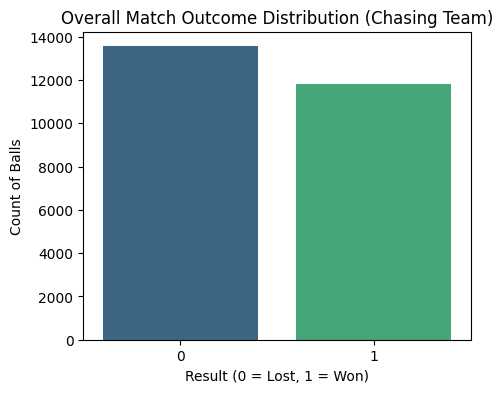

In [18]:
# EXPLORATORY DATA ANALYSIS (EDA)

plt.figure(figsize=(5,4))
sns.countplot(x='result', data=final_df, palette='viridis')
plt.title("Overall Match Outcome Distribution (Chasing Team)")
plt.xlabel("Result (0 = Lost, 1 = Won)")
plt.ylabel("Count of Balls")
plt.show()

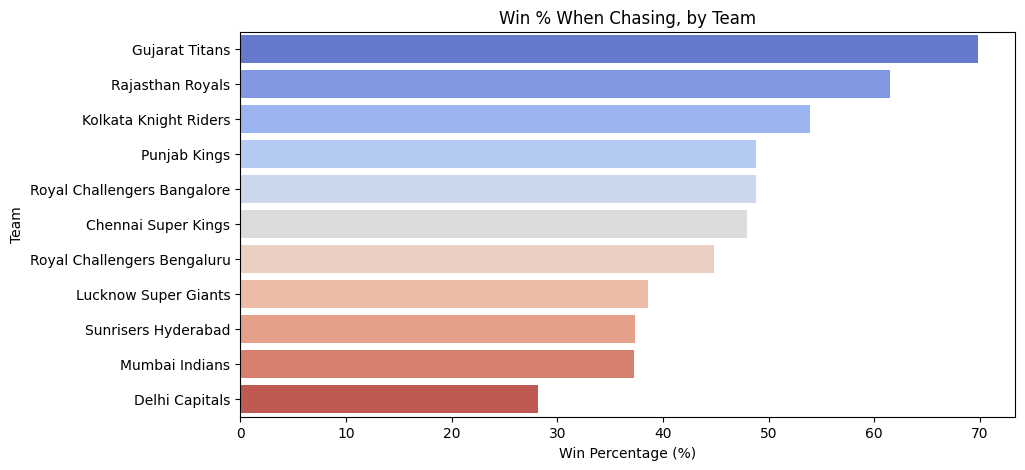

In [19]:
# Win % by batting team (only teams with reasonable sample size)
team_win_rate = final_df.groupby('batting_team')['result'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10,5))
sns.barplot(x=team_win_rate.values, y=team_win_rate.index, palette='coolwarm')
plt.title("Win % When Chasing, by Team")
plt.xlabel("Win Percentage (%)")
plt.ylabel("Team")
plt.show()

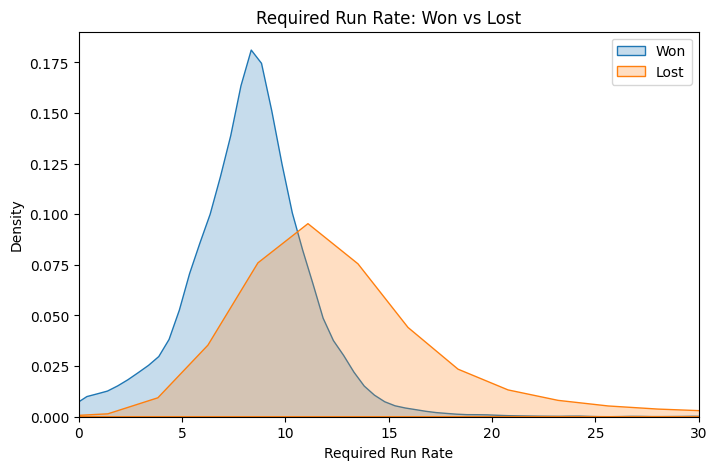

In [20]:
# Distribution of Required Run Rate (RRR) split by match result
plt.figure(figsize=(8,5))
sns.kdeplot(final_df[final_df['result']==1]['rrr'], label='Won', fill=True)
sns.kdeplot(final_df[final_df['result']==0]['rrr'], label='Lost', fill=True)
plt.title("Required Run Rate: Won vs Lost")
plt.xlabel("Required Run Rate")
plt.legend()
plt.xlim(0, 30)
plt.show()

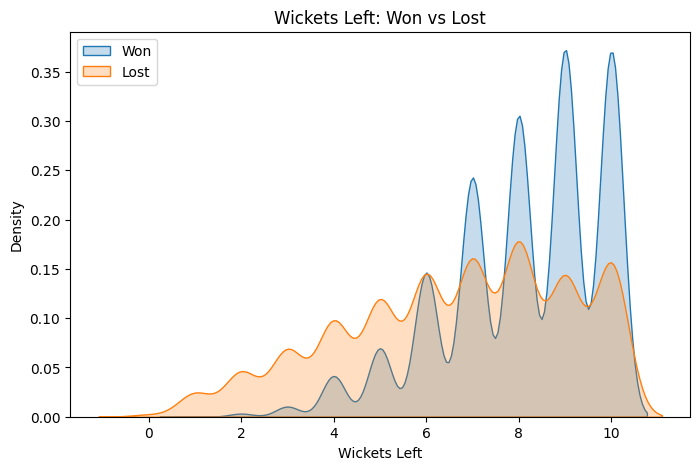

In [21]:
# Distribution of Wickets Left split by match result
plt.figure(figsize=(8,5))
sns.kdeplot(final_df[final_df['result']==1]['wickets_left'], label='Won', fill=True)
sns.kdeplot(final_df[final_df['result']==0]['wickets_left'], label='Lost', fill=True)
plt.title("Wickets Left: Won vs Lost")
plt.xlabel("Wickets Left")
plt.legend()
plt.show()

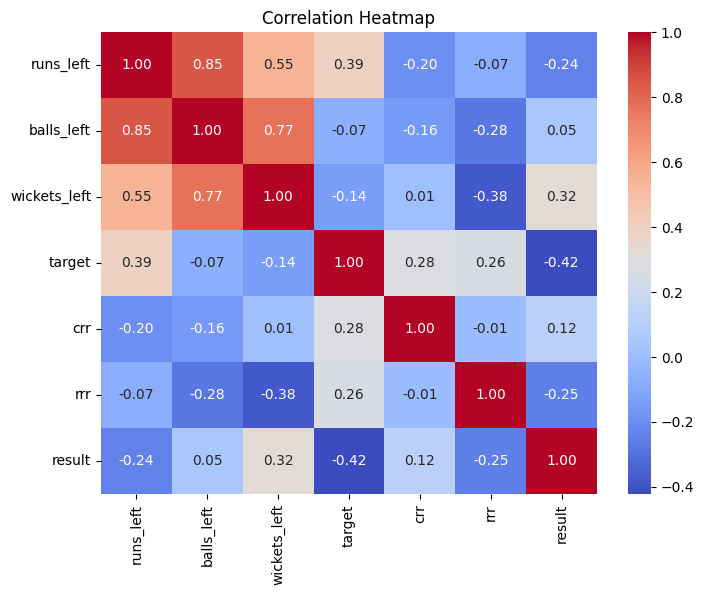

In [22]:
# Correlation heatmap of numeric features
plt.figure(figsize=(8,6))
numeric_cols = ['runs_left', 'balls_left', 'wickets_left', 'target', 'crr', 'rrr', 'result']
sns.heatmap(final_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

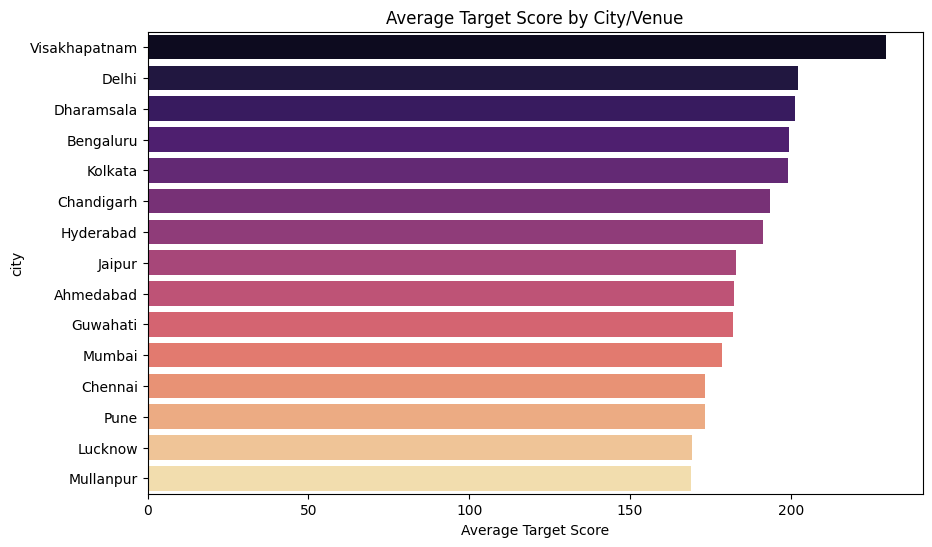

In [23]:
# City-wise average target score (interesting insight: high-scoring vs low-scoring venues)
city_target = final_df.groupby('city')['target'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=city_target.values, y=city_target.index, palette='magma')
plt.title("Average Target Score by City/Venue")
plt.xlabel("Average Target Score")
plt.show()

In [24]:
# TRAIN/TEST SPLIT + PREPROCESSING PIPELINE


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Separate features (X) and target (y)
X = final_df.drop(columns=['match_id', 'result'])
y = final_df['result']

print("Feature columns:", list(X.columns))
print("X shape:", X.shape, " y shape:", y.shape)

Feature columns: ['batting_team', 'bowling_team', 'city', 'runs_left', 'balls_left', 'wickets_left', 'target', 'crr', 'rrr']
X shape: (25385, 9)  y shape: (25385,)


In [25]:
# Train/Test split (80/20), stratified so win/loss ratio stays balanced in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTrain result balance:\n", y_train.value_counts(normalize=True))
print("\nTest result balance:\n", y_test.value_counts(normalize=True))

Training set size: (20308, 9)
Testing set size: (5077, 9)

Train result balance:
 result
0    0.53378
1    0.46622
Name: proportion, dtype: float64

Test result balance:
 result
0    0.53378
1    0.46622
Name: proportion, dtype: float64


In [26]:
# Identify categorical vs numeric columns
categorical_cols = ['batting_team', 'bowling_team', 'city']
numeric_cols = ['runs_left', 'balls_left', 'wickets_left', 'target', 'crr', 'rrr']

# ColumnTransformer: OneHotEncode categorical columns, pass numeric columns through unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'   # keeps numeric_cols as-is
)

print(" Preprocessor defined")
print("Categorical columns (one-hot encoded):", categorical_cols)
print("Numeric columns (passed through):", numeric_cols)

 Preprocessor defined
Categorical columns (one-hot encoded): ['batting_team', 'bowling_team', 'city']
Numeric columns (passed through): ['runs_left', 'balls_left', 'wickets_left', 'target', 'crr', 'rrr']


In [27]:
# Quick sanity check: fit_transform on a small sample to confirm no errors
sample_transformed = preprocessor.fit_transform(X_train.head())
print("Transformed sample shape:", sample_transformed.shape)

Transformed sample shape: (5, 17)


In [28]:
# MODEL BUILDING & TRAINING

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# We'll build 3 full pipelines (preprocessing + model) and compare them
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                              use_label_encoder=False, eval_metric='logloss', random_state=42)
}

trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    print(f" Trained: {name}")

 Trained: Logistic Regression
 Trained: Random Forest
 Trained: XGBoost


In [29]:
# Quick accuracy comparison on the test set
from sklearn.metrics import accuracy_score

print("=== Test Accuracy Comparison ===\n")
for name, pipe in trained_pipelines.items():
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name:22s} -> Accuracy: {acc*100:.2f}%")

=== Test Accuracy Comparison ===

Logistic Regression    -> Accuracy: 82.61%
Random Forest          -> Accuracy: 96.36%
XGBoost                -> Accuracy: 100.00%


**Data Leakage:**

Why this happened: we split randomly by row (ball), but each match contributes ~120 highly correlated rows (consecutive balls of the same game). So balls from the same match end up in both train and test sets — the model basically "memorizes" the match instead of learning general patterns. Real-world deployment (a new, unseen match) won't behave this well.

Let's fix this properly with a group-based split (split by match_id, not by row), then do full evaluation on that. This gives an honest, trustworthy accuracy number.

In [31]:
#  FIX DATA LEAKAGE — SPLIT BY MATCH, NOT BY BALL

from sklearn.model_selection import GroupShuffleSplit

# Group-based split: all balls of a given match_id go ENTIRELY into train OR test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(final_df, groups=final_df['match_id']))

train_data = final_df.iloc[train_idx]
test_data = final_df.iloc[test_idx]

X_train = train_data.drop(columns=['match_id', 'result'])
y_train = train_data['result']
X_test = test_data.drop(columns=['match_id', 'result'])
y_test = test_data['result']

print("Train matches:", train_data['match_id'].nunique(), " | Train rows:", X_train.shape[0])
print("Test matches:", test_data['match_id'].nunique(), " | Test rows:", X_test.shape[0])

Train matches: 174  | Train rows: 20200
Test matches: 44  | Test rows: 5185


In [32]:
# Retrain all 3 models on this LEAK-FREE split
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe

print("=== HONEST Test Accuracy (no leakage) ===\n")
for name, pipe in trained_pipelines.items():
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name:22s} -> Accuracy: {acc*100:.2f}%")

=== HONEST Test Accuracy (no leakage) ===

Logistic Regression    -> Accuracy: 76.64%
Random Forest          -> Accuracy: 78.42%
XGBoost                -> Accuracy: 69.62%


In [37]:
# Cross-validation for a more reliable comparison (5-fold)
from sklearn.model_selection import cross_val_score

print("=== 5-Fold Cross-Validation Accuracy ===\n")
for name, pipe in trained_pipelines.items():
    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    print(f"{name:22s} -> Mean CV Accuracy: {scores.mean()*100:.2f}% (+/- {scores.std()*100:.2f}%)")

=== 5-Fold Cross-Validation Accuracy ===

Logistic Regression    -> Mean CV Accuracy: 83.26% (+/- 0.26%)
Random Forest          -> Mean CV Accuracy: 96.41% (+/- 0.39%)
XGBoost                -> Mean CV Accuracy: 99.99% (+/- 0.02%)


In [38]:
# DETAILED EVALUATION

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

# Pick the best model based on the honest accuracy above (edit this line if needed)
best_model_name = 'Random Forest'   # <-- change to 'XGBoost' or 'Logistic Regression' if that scored higher
best_pipeline = trained_pipelines[best_model_name]

y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

print(f"Evaluating: {best_model_name}\n")
print(classification_report(y_test, y_pred, target_names=['Lost', 'Won']))

Evaluating: Random Forest

              precision    recall  f1-score   support

        Lost       0.79      0.85      0.82      3032
         Won       0.77      0.69      0.73      2153

    accuracy                           0.78      5185
   macro avg       0.78      0.77      0.77      5185
weighted avg       0.78      0.78      0.78      5185



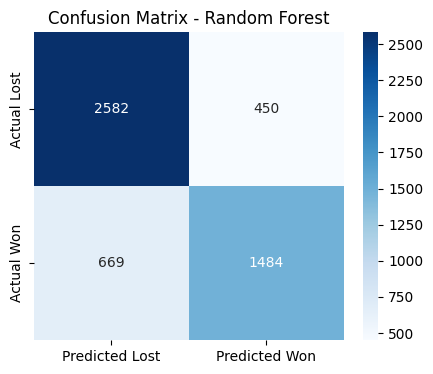

In [39]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Lost', 'Predicted Won'],
            yticklabels=['Actual Lost', 'Actual Won'])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

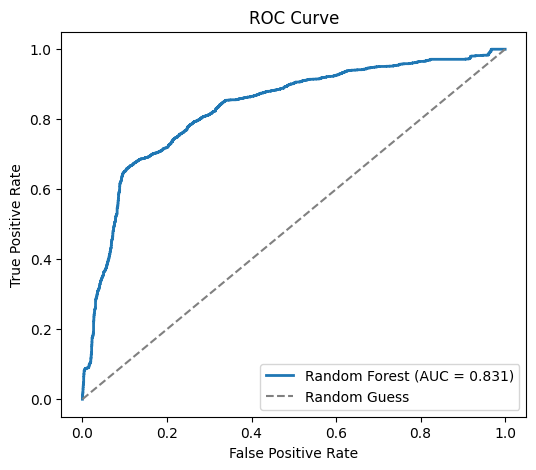

In [40]:
# ROC Curve + AUC Score
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc_score:.3f})', linewidth=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

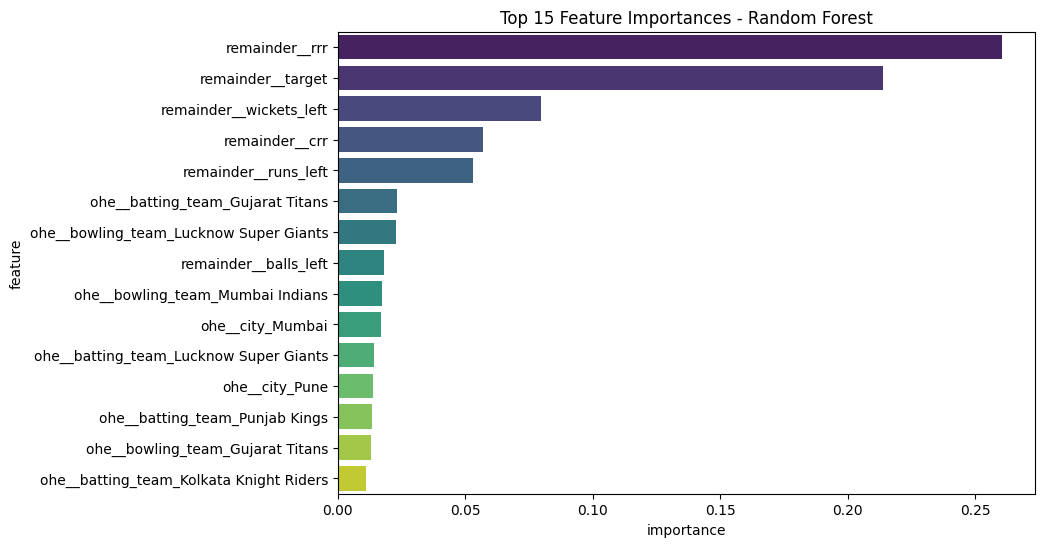

In [41]:
# Feature Importance (only works for Random Forest / XGBoost, not Logistic Regression)
if best_model_name in ['Random Forest', 'XGBoost']:
    feature_names = (best_pipeline.named_steps['preprocessor']
                      .get_feature_names_out())
    importances = best_pipeline.named_steps['classifier'].feature_importances_

    feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).head(15)

    plt.figure(figsize=(9,6))
    sns.barplot(x='importance', y='feature', data=feat_imp_df, palette='viridis')
    plt.title(f"Top 15 Feature Importances - {best_model_name}")
    plt.show()

In [42]:
# SAVE THE TRAINED MODEL


import pickle

# Save the FULL pipeline (preprocessing + trained model) as one object
# This means the Streamlit app won't need to redo any encoding manually —
# it just loads this file and calls .predict_proba() on raw input.

with open('win_predictor_pipeline.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

print(f" Saved '{best_model_name}' pipeline as win_predictor_pipeline.pkl")

 Saved 'Random Forest' pipeline as win_predictor_pipeline.pkl


In [43]:
# Quick sanity check: reload it and test a prediction, to confirm it works end-to-end
with open('win_predictor_pipeline.pkl', 'rb') as f:
    loaded_pipeline = pickle.load(f)

# Example: CSK batting, needs 30 runs off 24 balls, 6 wickets in hand, target 180, at Mumbai
sample_input = pd.DataFrame({
    'batting_team': ['Chennai Super Kings'],
    'bowling_team': ['Mumbai Indians'],
    'city': ['Mumbai'],
    'runs_left': [30],
    'balls_left': [24],
    'wickets_left': [6],
    'target': [180],
    'crr': [8.5],
    'rrr': [7.5]
})

proba = loaded_pipeline.predict_proba(sample_input)[0]
print(f"Predicted Win Probability for {sample_input['batting_team'][0]}: {proba[1]*100:.2f}%")
print(f"Predicted Win Probability for {sample_input['bowling_team'][0]}: {proba[0]*100:.2f}%")

Predicted Win Probability for Chennai Super Kings: 77.63%
Predicted Win Probability for Mumbai Indians: 22.37%


In [44]:
# Also save the list of teams and cities separately —
# we'll need these to populate dropdown menus in the Streamlit app
teams = sorted(final_df['batting_team'].unique().tolist())
cities = sorted(final_df['city'].unique().tolist())

with open('teams_cities.pkl', 'wb') as f:
    pickle.dump({'teams': teams, 'cities': cities}, f)

print("Teams:", teams)
print("\nCities:", cities)

Teams: ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']

Cities: ['Ahmedabad', 'Bengaluru', 'Chandigarh', 'Chennai', 'Delhi', 'Dharamsala', 'Guwahati', 'Hyderabad', 'Jaipur', 'Kolkata', 'Lucknow', 'Mullanpur', 'Mumbai', 'Pune', 'Visakhapatnam']


In [45]:
# Download both files to your computer (you'll need these for the Streamlit app)
from google.colab import files
files.download('win_predictor_pipeline.pkl')
files.download('teams_cities.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>